In [1]:
import polars as pl
import tensorflow as tf
import numpy as np

NUM_OF_TOKENS = 10


def prepare_data_lazy(file_path, num_prev=NUM_OF_TOKENS-1, batch_size=32, shuffle=False):
    """
    Prepare data for the transformer model using Polars and lazy loading, 
    with shuffling done by randomly selecting indices, and processing in batches.
    
    Args:
        file_path (str): Path to the CSV file.
        num_prev (int): Number of previous time frames to include.
        shuffle (bool): Whether to shuffle the data.
        batch_size (int): Number of rows to process in each batch.
    
    Yields:
        input_tensor (tf.Tensor): Tensor with shape (batch_size, num_prev + 1, 4).
        target_tensor (tf.Tensor): Tensor with shape (batch_size,).
    """
    # Load CSV lazily with Polars
    df_lazy = pl.scan_csv(file_path).select(['open_normalized', 'high_normalized', 'low_normalized', 'close_normalized', 'target'])

    # Collect the dataframe and determine total number of rows
    df_collected = df_lazy.collect()
    total_rows = df_collected.shape[0]

    # Create an array of indices to use for shuffling
    indices = list(range(num_prev, total_rows))

    # Shuffle indices if required
    if shuffle:
        np.random.shuffle(indices)

    input_list = []
    target_list = []

    # Pop random indices and process the corresponding data in batches
    while indices:
        batch_indices = [indices.pop(0) for _ in range(min(batch_size, len(indices)))]
        
        for idx in batch_indices:
            # Fetch the previous `num_prev + 1` rows for the input based on the current index
            input_rows = df_collected[idx - num_prev:idx + 1, :-1].to_numpy()  # Exclude 'target' for input
            target_value = df_collected[idx, -1]  # Include 'target' for the target

            input_list.append(input_rows)
            target_list.append(target_value)

        # Convert lists to NumPy arrays
        input_array = np.array(input_list)
        target_array = np.array(target_list)

        # Convert NumPy arrays to TensorFlow tensors
        input_tensor = tf.convert_to_tensor(input_array, dtype=tf.float32)
        target_tensor = tf.convert_to_tensor(target_array, dtype=tf.int32)

        yield input_tensor, target_tensor

        # Reset lists for the next batch
        input_list.clear()
        target_list.clear()



# Rest of your model building and training code remains unchanged
def create_dataset_generator(file_path, batch_size, shuffle=False):
    return tf.data.Dataset.from_generator(
        lambda: prepare_data_lazy(file_path, batch_size=batch_size, shuffle=shuffle),
        output_signature=(
            tf.TensorSpec(shape=(None, NUM_OF_TOKENS, 4), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.int32)
        )
    )


2024-09-27 10:01:30.284454: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-27 10:01:30.394563: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-27 10:01:30.394636: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-27 10:01:30.394715: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-27 10:01:30.427492: I tensorflow/core/platform/cpu_feature_g

In [2]:
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Dropout
from tensorflow.keras.models import Model
import numpy as np

# Positional Encoding remains the same
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, maxlen, d_model):
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(maxlen, d_model)

    def positional_encoding(self, maxlen, d_model):
        import numpy as np
        positions = np.arange(maxlen)[:, np.newaxis]
        angles = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (angles // 2)) / np.float32(d_model))
        angle_rads = positions * angle_rates

        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

# Transformer Block remains the same
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu"), Dense(embed_dim)]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Transformer Model
def build_transformer_model(input_shape, num_classes, d_model=32, num_heads=2, ff_dim=64, num_layers=2):
    inputs = Input(shape=input_shape)
    
    # Project the input (4 features per token) to the embedding dimension (d_model)
    x = Dense(d_model)(inputs)
    
    # Positional Encoding
    x = PositionalEncoding(input_shape[0], d_model)(x)
    
    # Transformer blocks
    for _ in range(num_layers):
        x = TransformerBlock(d_model, num_heads, ff_dim)(x)
    
    x = Dense(128, activation='relu')(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = Dropout(0.1)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.1)(x)
    
    # Output layer
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Rebuild and compile the model
input_shape = (NUM_OF_TOKENS, 4)  # 11 tokens, 4 features per token
num_classes = 3  # 3 possible classes for the target

model = build_transformer_model(input_shape, num_classes, d_model=32, ff_dim=64, num_heads=2, num_layers=2)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

2024-09-27 10:01:33.712257: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-09-27 10:01:33.740105: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-09-27 10:01:33.740144: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-09-27 10:01:33.743052: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-09-27 10:01:33.743086: I tensorflow/compile

In [3]:
train_dataset = create_dataset_generator('training/ADAUSD/train.csv', batch_size=32, shuffle=True).prefetch(tf.data.AUTOTUNE)
val_dataset = create_dataset_generator('training/ADAUSD/val.csv', batch_size=32).prefetch(tf.data.AUTOTUNE)
test_dataset = create_dataset_generator('training/ADAUSD/test.csv', batch_size=32).prefetch(tf.data.AUTOTUNE)

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)

# Evaluate the model using the test dataset
model.evaluate(test_dataset)


Epoch 1/10


2024-09-27 10:01:37.428144: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-09-27 10:01:38.165134: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x5594f5d14a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-09-27 10:01:38.165201: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2024-09-27 10:01:38.171667: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-09-27 10:01:38.194917: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2024-09-27 10:01:38.270846: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  28626/Unknown - 817s 28ms/step - loss: 0.3597 - accuracy: 0.8268

2024-09-27 10:15:11.621608: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 12578346708940711543
2024-09-27 10:15:11.621662: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 2528447242464494964
2024-09-27 10:15:11.621690: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 14042331325394472572


28628/28628 [==============================] - 940s 33ms/step - loss: 0.3597 - accuracy: 0.8268 - val_loss: 0.2518 - val_accuracy: 0.8794
Epoch 2/10
28628/28628 [==============================] - 971s 34ms/step - loss: 0.3336 - accuracy: 0.8276 - val_loss: 0.2438 - val_accuracy: 0.8814
Epoch 3/10
28628/28628 [==============================] - 1009s 35ms/step - loss: 0.3256 - accuracy: 0.8284 - val_loss: 0.2369 - val_accuracy: 0.8811
Epoch 4/10
28628/28628 [==============================] - 1003s 35ms/step - loss: 0.3209 - accuracy: 0.8284 - val_loss: 0.2414 - val_accuracy: 0.8846
Epoch 5/10
28628/28628 [==============================] - 1008s 35ms/step - loss: 0.3182 - accuracy: 0.8283 - val_loss: 0.2272 - val_accuracy: 0.8821
Epoch 6/10
28628/28628 [==============================] - 1006s 35ms/step - loss: 0.3154 - accuracy: 0.8296 - val_loss: 0.2620 - val_accuracy: 0.8844
Epoch 7/10
28628/28628 [==============================] - 972s 34ms/step - loss: 0.3141 - accuracy: 0.8302 - val_

2024-09-27 12:47:37.447708: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 14588725672051795059
2024-09-27 12:47:37.447805: I tensorflow/core/framework/local_rendezvous.cc:425] Local rendezvous send item cancelled. Key hash: 5492197066942989803
2024-09-27 12:47:37.447840: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 6837942676452366241
2024-09-27 12:47:37.447864: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 2528447242464494964


[0.3175414502620697, 0.8172013759613037]

In [19]:
test_dataset = create_dataset_generator('training/GBPUSD/test.csv', batch_size=32).prefetch(tf.data.AUTOTUNE)


In [21]:
x = model.predict(test_dataset)

42106/42106 [==============================] - 1200s 28ms/step


2024-09-27 14:37:28.311007: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 11351473190982752960
2024-09-27 14:37:28.311101: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 2623763667537863748


In [22]:
predicted_class =  tf.argmax(x, axis=1)

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
# Predict the classes for the test dataset
y_true = []
y_pred = []

for input_tensor, target_tensor in test_dataset:
#     predictions = model.predict(input_tensor)
#     predicted_classes = np.argmax(predictions, axis=1)  # Get the class with the highest score
    y_true.extend(target_tensor.numpy()) 

In [25]:
len(predicted_class), len(y_true)

(1347365, 1347365)

Confusion Matrix:
 [[1111104   24755       0]
 [  83036   21639       0]
 [ 106831       0       0]]


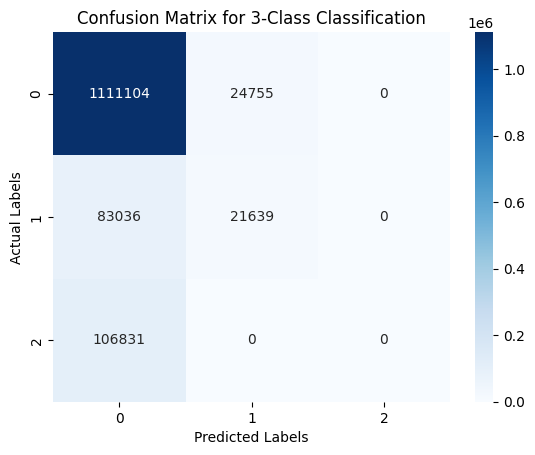

In [26]:
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Optionally: Visualize the confusion matrix using a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for 3-Class Classification')
plt.show()